#### **I. Import các thư viện**

In [90]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

#### **II. Import Data**

In [91]:

df = pd.read_csv('hanoi-aqi-weather-data.csv')  
df  

,UTC Time,Local Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,2022-12-31T17:00:00,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.00,62.3,87,0.0,1024,73,14.8,0.0,0.66
1,2022-12-31T18:00:00,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.00,59.0,87,0.0,1023,75,14.6,0.0,1.00
2,2022-12-31T19:00:00,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.00,58.0,83,0.0,1023,79,14.3,0.0,1.00
3,2022-12-31T20:00:00,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.00,57.0,79,0.0,1023,82,14.1,0.0,1.00
4,2022-12-31T21:00:00,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.00,56.0,75,0.0,1022,86,13.8,0.0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2024-12-31T08:00:00,12/31/2024 15:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,173,605.0,15.0,27.0,100.0,73.00,26.0,37,0.0,1018,82,16.8,0.0,2.00
17540,2024-12-31T09:00:00,12/31/2024 16:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,165,806.0,8.0,15.1,94.0,67.00,26.0,1,0.0,1018,86,16.0,0.0,2.00
17541,2024-12-31T10:00:00,12/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,183,1310.0,10.3,10.8,108.0,80.33,28.0,0,0.0,1018,90,15.2,0.0,2.00
17542,2024-12-31T11:00:00,12/31/2024 18:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,168,1109.0,15.0,10.8,96.0,69.00,32.0,1,0.0,1019,94,14.4,0.0,1.60


In [92]:
df_1 = df.copy()

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UTC Time           17544 non-null  object 
 1   Local Time         17544 non-null  object 
 2   City               17544 non-null  object 
 3   Country Code       17544 non-null  object 
 4   Timezone           17544 non-null  object 
 5   AQI                17544 non-null  int64  
 6   CO                 17544 non-null  float64
 7   NO2                17544 non-null  float64
 8   O3                 17544 non-null  float64
 9   PM10               17544 non-null  float64
 10  PM25               17544 non-null  float64
 11  SO2                17544 non-null  float64
 12  Clouds             17544 non-null  int64  
 13  Precipitation      17544 non-null  float64
 14  Pressure           17544 non-null  int64  
 15  Relative Humidity  17544 non-null  int64  
 16  Temperature        175

In [94]:
df.shape

(17544, 19)


Tập dữ liệu bao gồm dữ liệu hàng giờ trải dài 17544 hàng và 19 cột. Nó bao gồm khoảng thời gian từ 00:00:00 1/1/2023 đến 00:00:00 1/1/2025. Không có điểm dữ liệu bị thiếu trong khung dữ liệu.


- AQI: Air quality index
- CO: Carbon Monoxide (mg/m3)
- NO2: Nitrogen Dioxide (ug/m3)
- O3: Ozone (ug/m3)
- PM10: Particulate Matter 10 (ug/m3)
- PM25: Particulate Matter 2.5 (ug/m3)
- SO2: Sulfur Dioxide (ug/m3) 
- Clouds: Cloud Coverage (%)
- Precipitation: Precipitation (mm)
- Pressure: Atmospheric Pressure (hPa)
- Relative Humidity: Humidity (%)
- Temperature: Temperature (°C)
- UV Index: Ultraviolet Index
- Wind Speed: Wind Speed (m/s)

#### **II. Phân tích và khám phá dữ liệu**
Trong phần này, phân tích khám phá dữ liệu (EDA) sẽ được sử dụng để xem xét bộ dữ liệu nhằm tìm kiếm các khuôn mẫu, phát hiện bất thường, kiểm định giả thuyết và xác minh các giả định. Quá trình này được thực hiện thông qua các thống kê mô tả và biểu đồ trực quan.

Trong suốt hơn 45 năm qua, Chỉ số Chất lượng Không khí (Air Quality Index – AQI), được phát triển bởi Cơ quan Bảo vệ Môi trường Hoa Kỳ (USEPA), đã cung cấp những thông tin quan trọng cho công chúng về tình trạng ô nhiễm không khí.
Chỉ số AQI được tính toán dựa trên nồng độ đo được của các chất ô nhiễm bao gồm: Carbon Monoxide (CO), Nitrogen Dioxide (NO2), Ozone (O3), hạt bụi mịn PM2.5 và PM10, cùng với Sulfur Dioxide (SO2).

Trong đó, PM25 (biểu thị vật có đường kính nhỏ hơn hoặc bằng 2.5 micromet) là yếu tố chính gây nguy hại đến sức khỏe con người, và thường được sử dụng như chỉ tiêu quan trọng trong các tiêu chuẩn đánh giá chất lượng không khí.

Theo Báo cáo Chất lượng Không khí Toàn cầu năm 2019 của [IQAir](https://www.iqair.com/vi/newsroom/resources-what-is-aqi), nồng độ PM₂.₅ được chia thành các nhóm mức độ khác nhau để xác định tình trạng chất lượng không khí, cụ thể như sau:
![](./images/anh.png)


##### **2.1 Mô tả dữ liệu**

In [95]:
df.describe()

,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,119.188440,586.002194,26.046255,53.999806,69.853836,49.333772,66.193382,70.481190,0.287819,1009.855734,77.972811,25.367522,1.334131,1.616586
std,54.214466,969.613080,28.068960,44.883112,84.185750,42.314439,49.174271,31.187022,1.031729,7.434626,15.235786,5.479729,1.952395,0.820656
min,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,983.000000,17.000000,7.700000,0.000000,0.000000
25%,76.000000,135.400000,11.300000,22.300000,31.800000,24.000000,26.000000,50.000000,0.000000,1004.000000,68.000000,21.600000,0.000000,1.000000
50%,108.000000,212.400000,18.000000,41.700000,50.000000,38.000000,61.300000,79.000000,0.000000,1009.000000,82.000000,26.200000,0.600000,1.600000
75%,154.000000,571.300000,29.000000,74.000000,80.000000,59.000000,97.000000,100.000000,0.000000,1015.000000,91.000000,29.200000,2.100000,2.000000
max,500.000000,15956.200000,378.000000,700.000000,1103.000000,446.000000,400.000000,100.000000,21.750000,1033.000000,100.000000,40.000000,12.100000,12.400000


In [96]:
df.head(5)

,UTC Time,Local Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,2022-12-31T17:00:00,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
1,2022-12-31T18:00:00,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00
2,2022-12-31T19:00:00,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,83,0.0,1023,79,14.3,0.0,1.00
3,2022-12-31T20:00:00,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,79,0.0,1023,82,14.1,0.0,1.00
4,2022-12-31T21:00:00,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,75,0.0,1022,86,13.8,0.0,1.00


#### **2.2 AQI (Chỉ số chất lượng không khí)**
##### **2.2.1 AQI theo giờ của Hà Nội năm 2023, 2024**

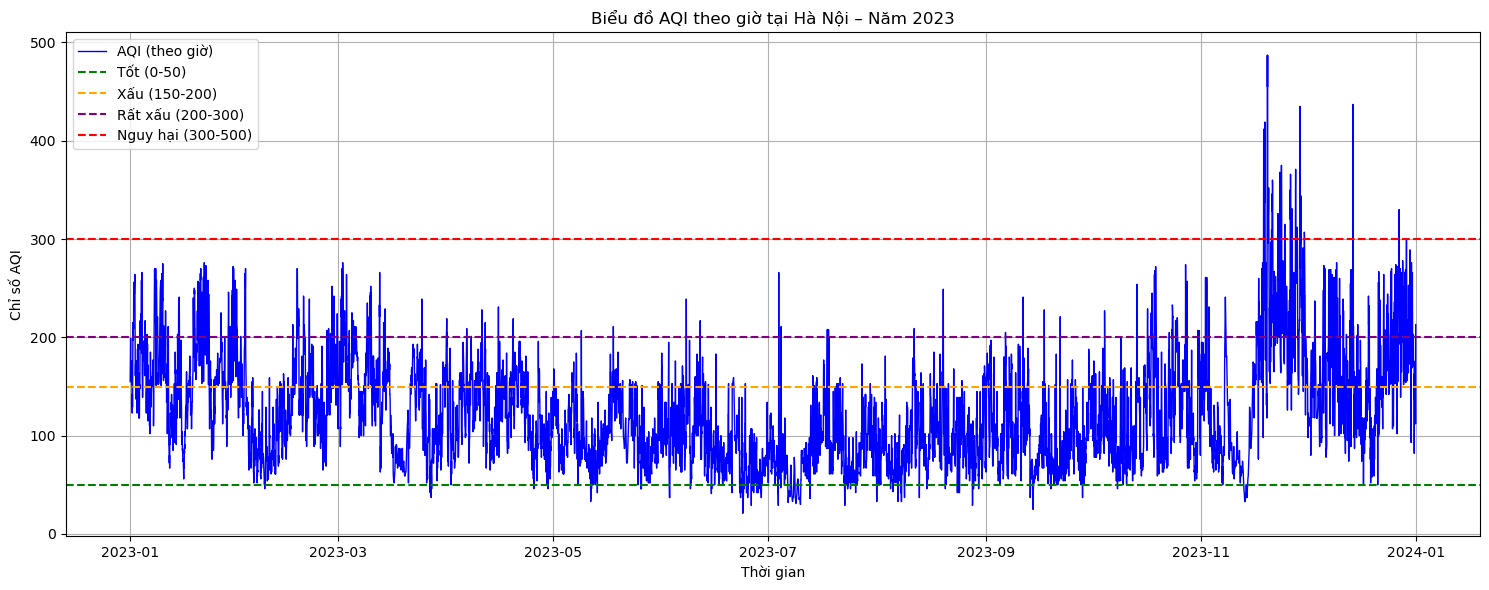

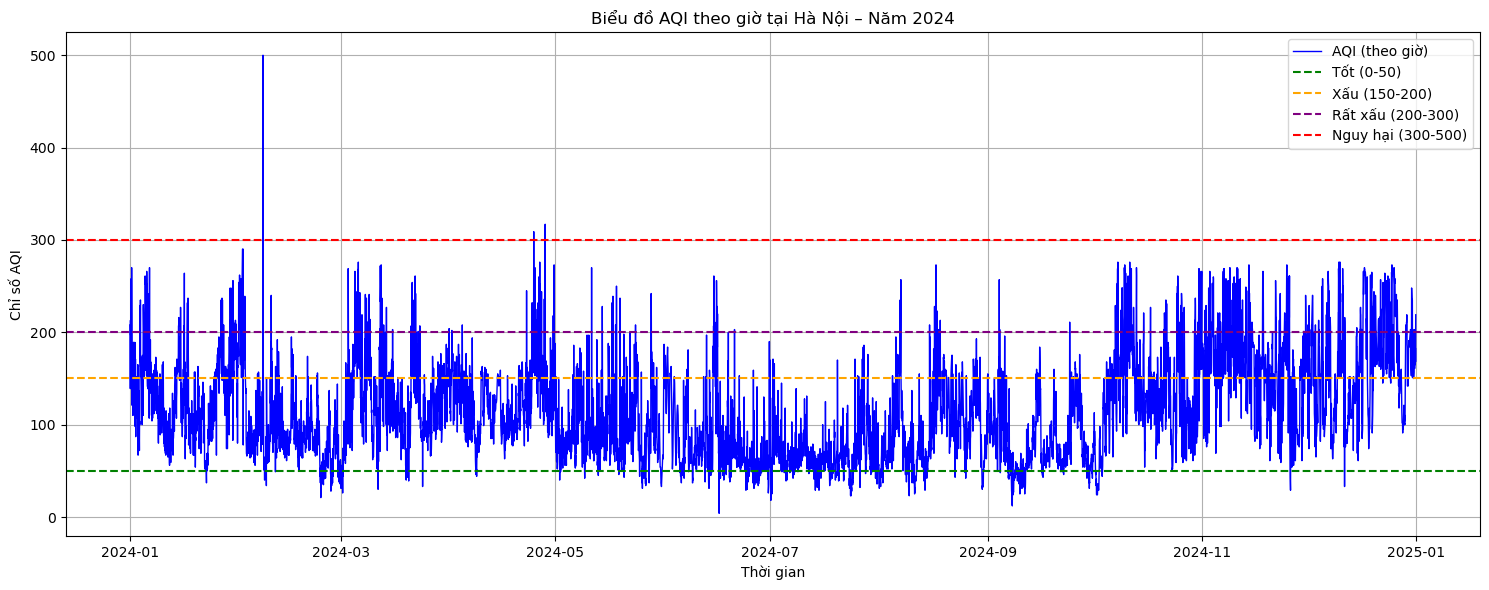

Năm 2023: AQI cao nhất = 487 vào lúc 2023-11-19 20:00:00
Năm 2024: AQI cao nhất = 500 vào lúc 2024-02-07 19:00:00


In [97]:
df['Local Time'] = pd.to_datetime(df['Local Time'])

df_2023 = df[df['Local Time'].dt.year == 2023]
df_2024 = df[df['Local Time'].dt.year == 2024]

# Biểu đồ năm 2023
plt.figure(figsize=(15,6))
plt.plot(df_2023['Local Time'], df_2023['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2023')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Biểu đồ năm 2024
plt.figure(figsize=(15,6))
plt.plot(df_2024['Local Time'], df_2024['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2024')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


max_2023 = df_2023.loc[df_2023['AQI'].idxmax()]
max_2024 = df_2024.loc[df_2024['AQI'].idxmax()]
print(f"Năm 2023: AQI cao nhất = {max_2023['AQI']} vào lúc {max_2023['Local Time']}")
print(f"Năm 2024: AQI cao nhất = {max_2024['AQI']} vào lúc {max_2024['Local Time']}")


**-> KẾT LUẬN:** Từ biểu đồ, có thể thấy chỉ số AQI của Hà Nội dao động chủ yếu trong khoảng 50-200 (Trung bình đến Xấu). Chỉ số này ít khi duy trì ở mức "Tốt" (0-50). Chỉ số cũng có tần suất cao vượt ngưỡng "Không tốt". Đặc biệt, chỉ số này ở mức "Nguy hại" (>300) vào các thời điểm khác nhau từ tháng 11 đến giữa tháng 2, đạt mức cao nhất trong năm vào lúc 19h 7/2/2024 và đạt AQI = 487 vào lúc 20h ngày 19/11/2023.

Nhìn chung, Hà Nội đã phải đối mặt với tình trạng ô nhiễm không khí nghiêm trọng trong năm qua, điều này có thể ảnh hưởng nghiêm trọng đến sức khỏe của người dân thành phố.



##### **2.2.2 Các tháng có AQI ở mức "Nguy hại"**

In [98]:

df['month'] = df['Local Time'].dt.month
df['year'] = df['Local Time'].dt.year

monthly_stats = (df.groupby(['year', 'month']).agg(
    mean_AQI = ('AQI', 'mean'),
    max_AQI = ('AQI', 'max'),
    std_AQI = ('AQI', 'std'),
    count_hazardous=('AQI', lambda x: (x>300).sum())
    
).reset_index()
                )
monthly_stats = monthly_stats.sort_values('mean_AQI', ascending=False)
months_over_300 = monthly_stats[monthly_stats['count_hazardous'] > 0]
print(months_over_300[['year', 'month', 'mean_AQI', 'count_hazardous']])


    year  month    mean_AQI  count_hazardous
10  2023     11  166.684722               52
11  2023     12  165.413978                2
15  2024      4  128.120666                2
13  2024      2   96.771552                1


In [99]:
df_1['Local Time'] = pd.to_datetime(df_1['Local Time'])


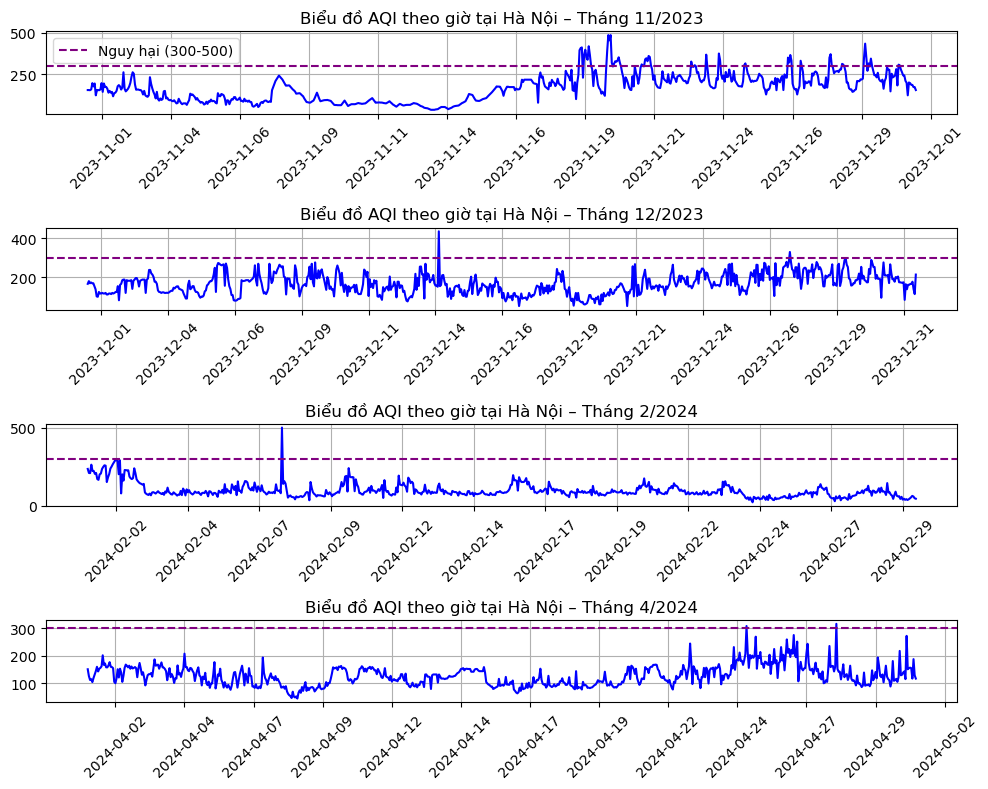

In [100]:
fig, axs = plt.subplots(4, 1, figsize=(10, 8))

df_1 = df_1.set_index('Local Time')

# Vẽ biểu đồ cho từng tháng
axs[0].plot(df_1.loc['2023-11-01':'2023-11-30']["AQI"], color='b')
axs[0].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 11/2023')
axs[0].grid(True)
axs[0].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')
axs[0].legend()


axs[1].plot(df_1.loc['2023-12-01':'2023-12-31']["AQI"], color='b')
axs[1].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 12/2023')
axs[1].grid(True)
axs[1].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[2].plot(df_1.loc['2024-02-01':'2024-02-29']["AQI"], color='b')
axs[2].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 2/2024')
axs[2].grid(True)
axs[2].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[3].plot(df_1.loc['2024-04-01':'2024-04-30']["AQI"], color='b')
axs[3].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 4/2024')
axs[3].grid(True)
axs[3].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(15))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Các tháng có mức AQI nguy hiểm là tháng 11, 12, 2, 4. Khi xem xét ba biểu đồ được cung cấp, có thể thấy rõ rằng tháng 11 chứng kiến ​​sự xuất hiện thường xuyên của các mức AQI nguy hiểm, đặc biệt là trong nửa cuối tháng. Ngược lại, tháng 12, 2, 4 chỉ có một ngày AQI đạt đến mức nguy hiểm.

Nguyên nhân xảy ra sự cố tháng 11 đã được VnExpress giải thích trong bài [“Chất lượng không khí Hà Nội giảm xuống mức nguy hại”](https://vnexpress.net/chat-luong-khong-khi-ha-noi-dang-rat-xau-4834405.html). Theo bài báo, Cục Kiểm soát ô nhiễm Việt Nam lưu ý rằng điều kiện thời tiết khô hạn ở Hà Nội khiến bụi phát tán trên diện rộng. Ngoài ra, việc đốt rác và nông sản còn sót lại được xác định là góp phần làm tăng mức độ ô nhiễm.

##### **2.3 Nồng độ bụi mịn PM2.5**
Theo [VnExpress](https://e.vnexpress.net/news/environment/hanoi-s-air-quality-dropping-over-large-scales-4719205.html), nghiên cứu của Bộ Tài nguyên và Môi trường Việt Nam chỉ ra rằng ô nhiễm không khí ở Hà Nội chủ yếu đến từ bụi PM2.5 ảnh hưởng nặng nề đến sức khỏe người dân. Vì vậy, chúng ta sẽ có cái nhìn sâu hơn về chỉ số PM2.5 của Hà Nội trong năm 2023, 2024.
##### **2.3.1 Biểu đồ tỉ lệ PM2.5 theo giờ trong năm 2023 và 2024**

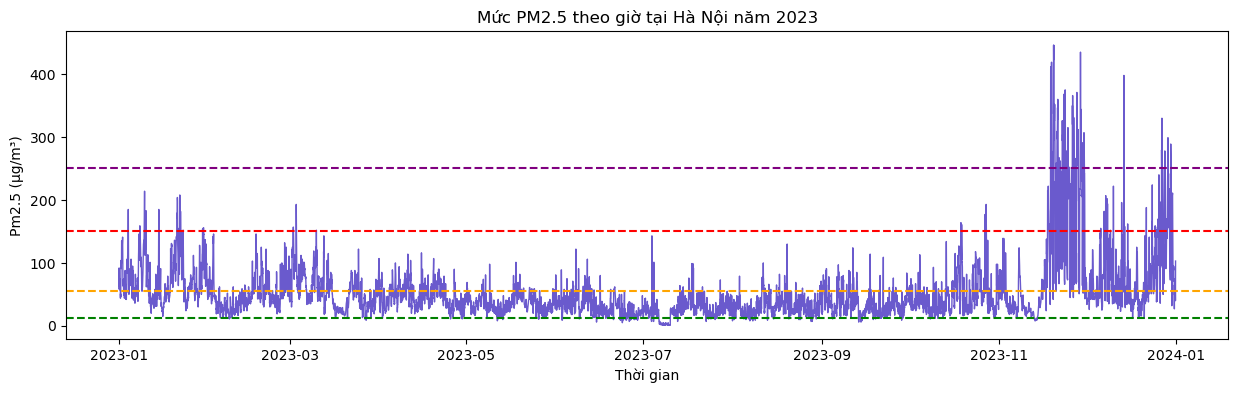

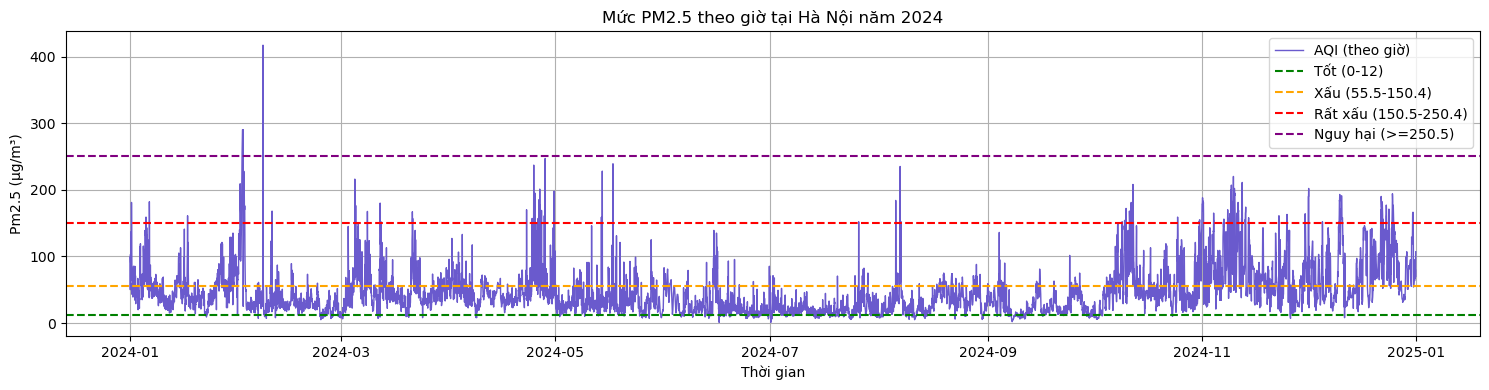

In [101]:
# Năm 2023

plt.figure(figsize=(15, 4))
plt.plot(df_2023['Local Time'], df_2023['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2023')
plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')

# Năm 2024
plt.figure(figsize=(15, 4))
plt.plot(df_2024['Local Time'], df_2024['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2024')

plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')


plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

**-> KẾT LUẬN:** Từ 2 biểu đồ ta quan sát thấy đấy nồng độ PM2.5 và AQI có xu hướng biến động tương đương nhau. Bên cạnh đó, PM2.5 rất ít khi ở mức "Tốt"

##### **2.3.2 Những giờ có nồng độ PM2.5 cao nhất trong ngày**

In [102]:
df = df.reset_index()
df.head(2)

,index,UTC Time,Local Time,City,Country Code,Timezone,AQI,CO,NO2,O3,...,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,month,year
0,0,2022-12-31T17:00:00,2023-01-01 00:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,...,62.3,87,0.0,1024,73,14.8,0.0,0.66,1,2023
1,1,2022-12-31T18:00:00,2023-01-01 01:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,...,59.0,87,0.0,1023,75,14.6,0.0,1.00,1,2023


In [103]:

df['Local Time'] = pd.to_datetime(df['Local Time'], errors='coerce')


hourly_pm25 = df.groupby(df['Local Time'].dt.hour)['PM25'].mean()
highest_hours = hourly_pm25.nlargest(5).round(2) 
print(highest_hours)

Local Time
8     56.33
20    55.92
9     55.45
21    54.53
6     54.37
Name: PM25, dtype: float64


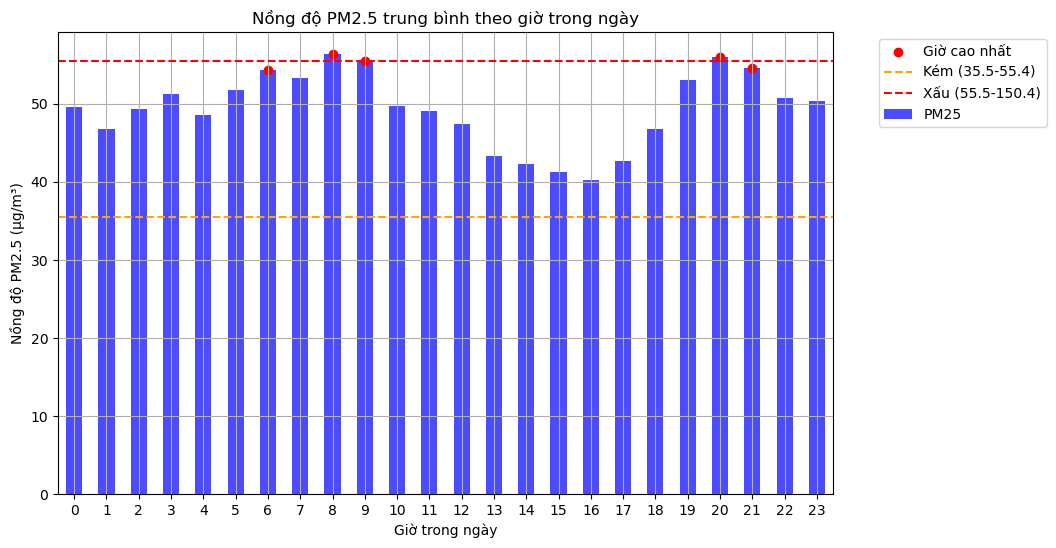

In [104]:


df['Local Time'] = pd.to_datetime(df['Local Time'], errors='coerce')


plt.figure(figsize=(10, 6))
hourly_pm25.plot(kind='bar', color='blue', alpha=0.7)  
plt.scatter(highest_hours.index, highest_hours.values, color='red', label='Giờ cao nhất') 
plt.title('Nồng độ PM2.5 trung bình theo giờ trong ngày')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.xticks(rotation='horizontal')

plt.show()


**-> KẾT LUẬN:**
Từ biểu đồ trên, có thể thấy nồng độ PM2.5 trung bình trong ngày tại Hà Nội dao động quanh mức 50–56 µg/m³, vượt ngưỡng “Kém” (35.5 µg/m³) và tiệm cận ngưỡng “Xấu” (55.5 µg/m³).

Cụ thể, các giờ có nồng độ cao nhất tập trung vào buổi sáng (6–9h) và buổi tối (19–21h) — trùng với hai khung giờ cao điểm giao thông, đồng thời điều kiện khuếch tán khí kém do hiện tượng [nghịch nhiệt](https://aqualife.vn/hien-tuong-nghich-nhiet-va-nhung-tac-hai-den-moi-truong-va-suc-khoe/) và tốc độ gió thấp.

Điều này cho thấy, hoạt động giao thông đô thị kết hợp với điều kiện khí tượng bất lợi về đêm là nguyên nhân chính khiến PM2.5 tăng cao, gây ra tình trạng ô nhiễm không khí nghiêm trọng trong các khoảng thời gian này.

##### **2.3.3 Nồng độ PM2.5 trung bình mỗi mùa**

In [105]:
df_2 = df.copy()
df_2.reset_index()
df_2['Local Time'] = pd.to_datetime(df_2['Local Time'], errors='coerce')
df_2 = df_2.set_index('Local Time')
df_2


,index,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,...,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,month,year
Local Time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,0,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,...,62.3,87,0.0,1024,73,14.8,0.0,0.66,1,2023
2023-01-01 01:00:00,1,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,...,59.0,87,0.0,1023,75,14.6,0.0,1.00,1,2023
2023-01-01 02:00:00,2,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,...,58.0,83,0.0,1023,79,14.3,0.0,1.00,1,2023
2023-01-01 03:00:00,3,2022-12-31T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,...,57.0,79,0.0,1023,82,14.1,0.0,1.00,1,2023
2023-01-01 04:00:00,4,2022-12-31T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,...,56.0,75,0.0,1022,86,13.8,0.0,1.00,1,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 15:00:00,17539,2024-12-31T08:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,173,605.0,15.0,27.0,100.0,...,26.0,37,0.0,1018,82,16.8,0.0,2.00,12,2024
2024-12-31 16:00:00,17540,2024-12-31T09:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,165,806.0,8.0,15.1,94.0,...,26.0,1,0.0,1018,86,16.0,0.0,2.00,12,2024
2024-12-31 17:00:00,17541,2024-12-31T10:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,183,1310.0,10.3,10.8,108.0,...,28.0,0,0.0,1018,90,15.2,0.0,2.00,12,2024


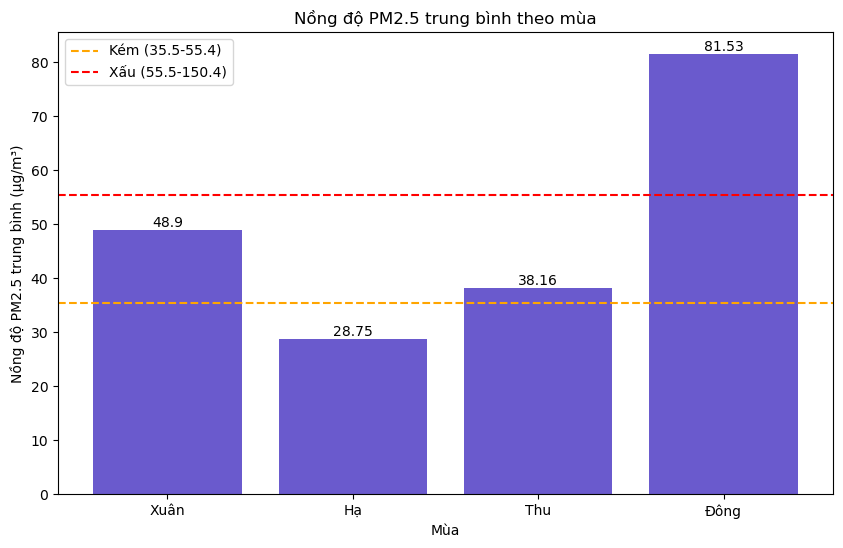

In [106]:
seasons = {
    'Xuân': [2, 3, 4],
    'Hạ': [5, 6, 7],
    'Thu': [8, 9, 10],
    'Đông': [11, 12, 1]
}


seasonal_pm25 = {}
for season, months in seasons.items():
    seasonal_pm25[season] = df_2.loc[df_2.index.month.isin(months), 'PM25'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_pm25.keys(), seasonal_pm25.values(), color='slateblue')
plt.title('Nồng độ PM2.5 trung bình theo mùa')
plt.xlabel('Mùa')
plt.ylabel('Nồng độ PM2.5 trung bình (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')
plt.legend()


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

**-> KẾT LUẬN:**
+ Mùa Đông ghi nhận mức cao nhất (≈ 81.53 µg/m³) — vượt xa ngưỡng “Xấu” (55.5 µg/m³).
→ Điều này do thời tiết lạnh, ít gió, độ ẩm cao và hiện tượng nghịch nhiệt làm bụi mịn tích tụ gần mặt đất.
+ Mùa Xuân cũng có mức PM2.5 tương đối cao (≈ 48.9 µg/m³), nằm trong vùng “Kém”.
+ Mùa Thu ở mức trung bình (≈ 38.16 µg/m³), thấp hơn so với mùa Xuân nhưng vẫn vượt ngưỡng an toàn.
+ Mùa Hè là mùa có chất lượng không khí tốt nhất, với PM2.5 trung bình chỉ ≈ 28.75 µg/m³, nhờ mưa nhiều, gió mạnh và đối lưu không khí tốt.


Nồng độ PM2.5 ở Hà Nội cao nhất vào mùa Đông – Xuân và thấp nhất vào mùa Hè, cho thấy điều kiện khí tượng và thời tiết có ảnh hưởng rõ rệt đến mức độ ô nhiễm không khí của thành phố.

# **2.4 Mưa**


In [107]:
df_2.describe()



,index,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,month,year
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,8771.500000,119.188440,586.002194,26.046255,53.999806,69.853836,49.333772,66.193382,70.481190,0.287819,1009.855734,77.972811,25.367522,1.334131,1.616586,6.518810,2023.500684
std,5064.660897,54.214466,969.613080,28.068960,44.883112,84.185750,42.314439,49.174271,31.187022,1.031729,7.434626,15.235786,5.479729,1.952395,0.820656,3.449225,0.500014
min,0.000000,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,983.000000,17.000000,7.700000,0.000000,0.000000,1.000000,2023.000000
25%,4385.750000,76.000000,135.400000,11.300000,22.300000,31.800000,24.000000,26.000000,50.000000,0.000000,1004.000000,68.000000,21.600000,0.000000,1.000000,4.000000,2023.000000
50%,8771.500000,108.000000,212.400000,18.000000,41.700000,50.000000,38.000000,61.300000,79.000000,0.000000,1009.000000,82.000000,26.200000,0.600000,1.600000,7.000000,2024.000000
75%,13157.250000,154.000000,571.300000,29.000000,74.000000,80.000000,59.000000,97.000000,100.000000,0.000000,1015.000000,91.000000,29.200000,2.100000,2.000000,10.000000,2024.000000
max,17543.000000,500.000000,15956.200000,378.000000,700.000000,1103.000000,446.000000,400.000000,100.000000,21.750000,1033.000000,100.000000,40.000000,12.100000,12.400000,12.000000,2024.000000


## 2.4.1 ☔ Phân tích lượng mưa theo giờ

Lượng mưa là một trong những yếu tố khí tượng quan trọng nhất, ảnh hưởng trực tiếp đến **chất lượng không khí**, **khả năng phát tán bụi**, và **tình trạng ô nhiễm PM2.5**.  
Phần này trình bày **biểu đồ lượng mưa theo thời gian**, được tô màu để thể hiện các **mùa khí tượng** tại Hà Nội.

### 🌦️ Cấu trúc biểu đồ
- **Đường màu xanh đậm:** Lượng mưa (mm) theo giờ trong năm  
- **Các vùng màu mờ:** Tô theo mùa khí tượng  
  - 🟦 *Mùa Đông:* tháng 11–12–1  
  - 🟩 *Mùa Xuân:* tháng 2–3–4  
  - 🟨 *Mùa Hè:* tháng 5–6–7  
  - 🟫 *Mùa Thu:* tháng 8–9–10  

### 📈 Ý nghĩa và diễn giải
- **Mùa Hè** là giai đoạn có lượng mưa cao nhất, đặc trưng bởi các cơn mưa rào, mưa giông do gió mùa Tây Nam.  
- **Mùa Đông** hầu như **ít mưa**, độ ẩm cao nhưng lượng nước rơi nhỏ.  
- **Mùa Xuân và Mùa Thu** thể hiện giai đoạn chuyển tiếp, lượng mưa dao động nhẹ.  

### 💧 Kết quả
- Tổng lượng mưa trong năm được tính tự động bằng Python.  
- Phân tích xu hướng giúp xác định mối tương quan giữa lượng mưa và **sự suy giảm bụi mịn PM2.5**, hỗ trợ trong nghiên


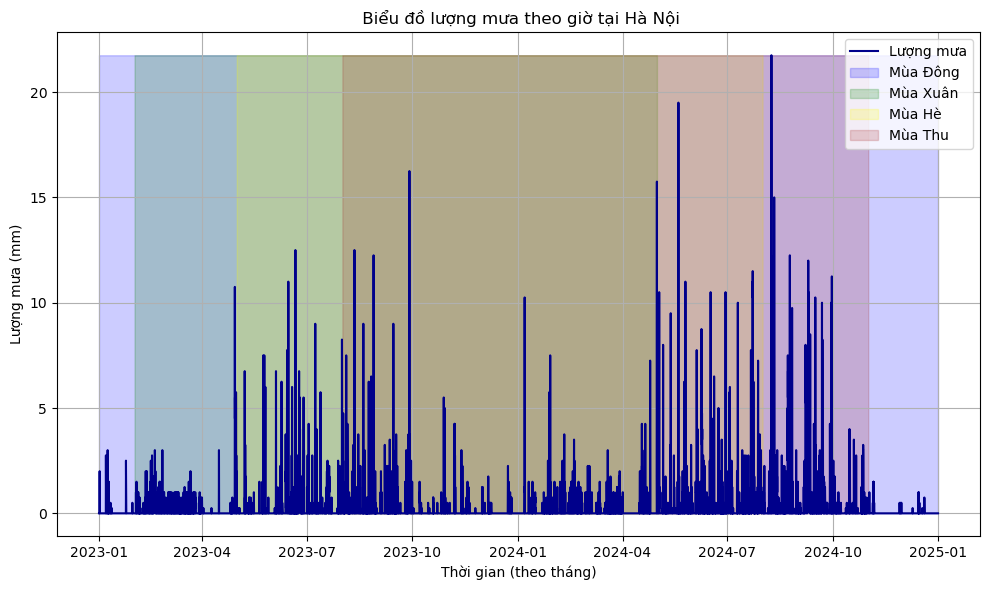

Tổng lượng mưa năm: 5049.5 mm


In [108]:
# --- Đảm bảo index là kiểu thời gian ---
df_2.index = pd.to_datetime(df_2.index)

# --- Xác định các mùa ---
mua_dong = [11, 12, 1]
mua_xuan = [2, 3, 4]
mua_he = [5, 6, 7]
mua_thu = [8, 9, 10]

# --- Vẽ biểu đồ lượng mưa ---
plt.figure(figsize=(10, 6))

# Biểu diễn lượng mưa theo thời gian
plt.plot(df_2.index, df_2['Precipitation'], color='darkblue', label='Lượng mưa')

# --- Tô màu các mùa ---
plt.fill_between(df_2.index[df_2.index.month.isin(mua_dong)],
                 df_2['Precipitation'].min(), df_2['Precipitation'].max(),
                 color='blue', alpha=0.2, label='Mùa Đông')

plt.fill_between(df_2.index[df_2.index.month.isin(mua_xuan)],
                 df_2['Precipitation'].min(), df_2['Precipitation'].max(),
                 color='green', alpha=0.2, label='Mùa Xuân')

plt.fill_between(df_2.index[df_2.index.month.isin(mua_he)],
                 df_2['Precipitation'].min(), df_2['Precipitation'].max(),
                 color='yellow', alpha=0.2, label='Mùa Hè')

plt.fill_between(df_2.index[df_2.index.month.isin(mua_thu)],
                 df_2['Precipitation'].min(), df_2['Precipitation'].max(),
                 color='brown', alpha=0.2, label='Mùa Thu')

# --- Thiết lập tiêu đề và nhãn ---
plt.title(' Biểu đồ lượng mưa theo giờ tại Hà Nội')
plt.xlabel('Thời gian (theo tháng)')
plt.ylabel('Lượng mưa (mm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Tổng lượng mưa năm ---
tong_luong_mua_nam = df_2['Precipitation'].sum()
print("Tổng lượng mưa năm:", round(tong_luong_mua_nam, 2), "mm")


#### **2.4.2 Tổng lượng mưa theo mùa**

## 2.4.2 💦 Biểu đồ tổng lượng mưa theo mùa 

Sau khi trực quan hóa lượng mưa theo thời gian, phần này tổng hợp lượng mưa trung bình của từng mùa để nhận diện sự **phân bố mưa theo chu kỳ khí hậu** trong năm.

### 🌤️ Phân chia mùa khí tượng
| Mùa | Các tháng | Đặc điểm khí hậu |
|:--|:--|:--|
| 🌸 **Mùa Xuân** | 2 – 3 – 4 | Thời tiết ẩm, có mưa phùn nhẹ |
| ☀️ **Mùa Hè** | 5 – 6 – 7 | Mưa rào, giông lớn, lượng mưa cao nhất năm |
| 🍂 **Mùa Thu** | 8 – 9 – 10 | Trời khô ráo, mưa giảm dần |
| ❄️ **Mùa Đông** | 11 – 12 – 1 | Ít mưa, độ ẩm cao, lạnh khô |

### 📊 Nội dung biểu đồ
- Biểu đồ cột thể hiện **tổng lượng mưa (mm)** của từng mùa trong năm.  
- Mỗi cột được ghi rõ **giá trị tổng lượng mưa**, giúp dễ dàng so sánh.  
- Dữ liệu được tính toán tự động từ trường `Precipitation` trong DataFrame `df_2`.

### 💡 Nhận xét khí hậu
- **Mùa Hè** thường chiếm hơn **50% tổng lượng mưa cả năm**, đặc trưng bởi ảnh hưởng của gió mùa Tây Nam.  
- **Mùa Đông** hầu như **ít mưa**, lượng nước bốc hơi thấp.  
- **Xuân và Thu** là giai đoạn chuyển tiếp với lượng mưa vừa p


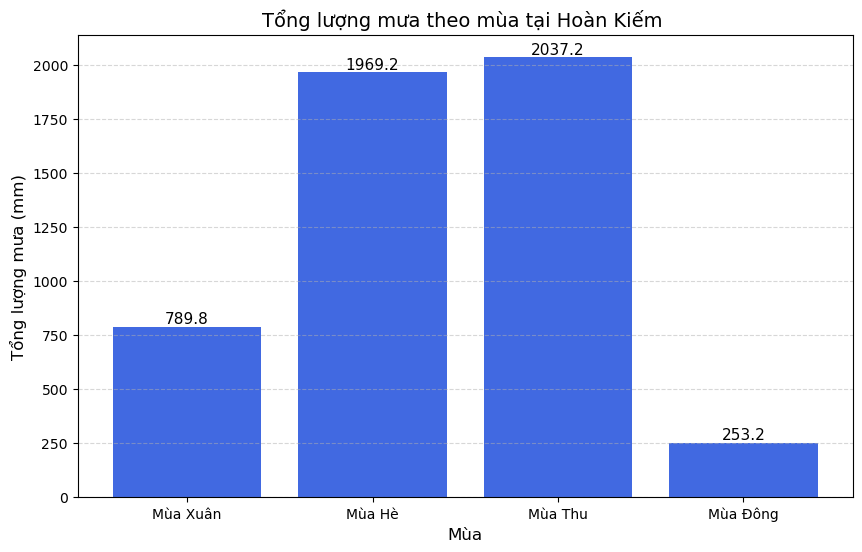

In [109]:



# Xác định các mùa trong năm (theo tháng)
cac_mua = {
    'Mùa Xuân': [2, 3, 4],
    'Mùa Hè': [5, 6, 7],
    'Mùa Thu': [8, 9, 10],
    'Mùa Đông': [11, 12, 1]
}

# Tính tổng lượng mưa theo từng mùa
luong_mua_theo_mua = {}
for mua, cac_thang in cac_mua.items():
    luong_mua_theo_mua[mua] = df_2.loc[df_2.index.month.isin(cac_thang), 'Precipitation'].sum()

# Vẽ biểu đồ cột thể hiện tổng lượng mưa theo mùa
plt.figure(figsize=(10, 6))
cot = plt.bar(luong_mua_theo_mua.keys(), luong_mua_theo_mua.values(), color='royalblue')

# Tiêu đề và nhãn trục
plt.title('Tổng lượng mưa theo mùa tại Hoàn Kiếm ', fontsize=14)
plt.xlabel('Mùa', fontsize=12)
plt.ylabel('Tổng lượng mưa (mm)', fontsize=12)

# Ghi giá trị lên đầu cột
for c in cot:
    chieu_cao = c.get_height()
    plt.text(c.get_x() + c.get_width()/2, chieu_cao, f"{round(chieu_cao, 1)}", 
             ha='center', va='bottom', fontsize=11, color='black')

# Hiển thị biểu đồ
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


# 2.5 **Áp suất**
## 2.5.1 🌡️ Phân tích sự biến động áp suất không khí theo thời gian tại Hà Nội 

Áp suất không khí (đơn vị **hPa**) là chỉ tiêu quan trọng trong khí tượng học, phản ánh **trọng lượng của không khí** tác động lên bề mặt Trái Đất.  
Biến động áp suất ảnh hưởng đến **sự di chuyển của không khí, hình thành gió và các hiện tượng thời tiết** như mưa, bão hay không khí lạnh.

### 📈 Thông tin biểu đồ
- **Trục X:** Thời gian (giờ, trong năm 2023)  
- **Trục Y:** Áp suất (hPa)  
- **Đường màu tím:** Áp suất thực tế theo thời gian  
- **Đường đứt đỏ:** Áp suất tiêu chuẩn (1013 hPa)  
- **Vùng màu nền:** Biểu thị bốn mùa trong năm:
  - 🩵 **Mùa Đông:** Tháng 11–1  
  - 💚 **Mùa Xuân:** Tháng 2–4  
  - 💛 **Mùa Hè:** Tháng 5–7  
  - 🧡 **Mùa Thu:** Tháng 8–10  

### 🎯 Mục tiêu phân tích
- Theo dõi **xu hướng biến động áp suất trong năm**.  
- Nhận biết **các đợt áp thấp hoặc áp cao** bất thường.  
- So sánh áp suất trung bình theo mùa với **mức chuẩn 1013 hPa**.

### 📊 Nhận xét gợi ý
- **Áp suất thường giảm nhẹ vào mùa Hè**, do nhiệt độ cao làm không khí giãn nở.  
- **Mùa Đông có xu hướng áp suất cao hơn**, gắn liền với khối không khí lạnh từ phương Bắc.  
- Biểu đồ cho thấy **dao động nhỏ quanh mức 1010–1020 hPa**, phản ánh trạng thái khí quyển ổn định của khu vực đồng bằng Bắc Bộ.


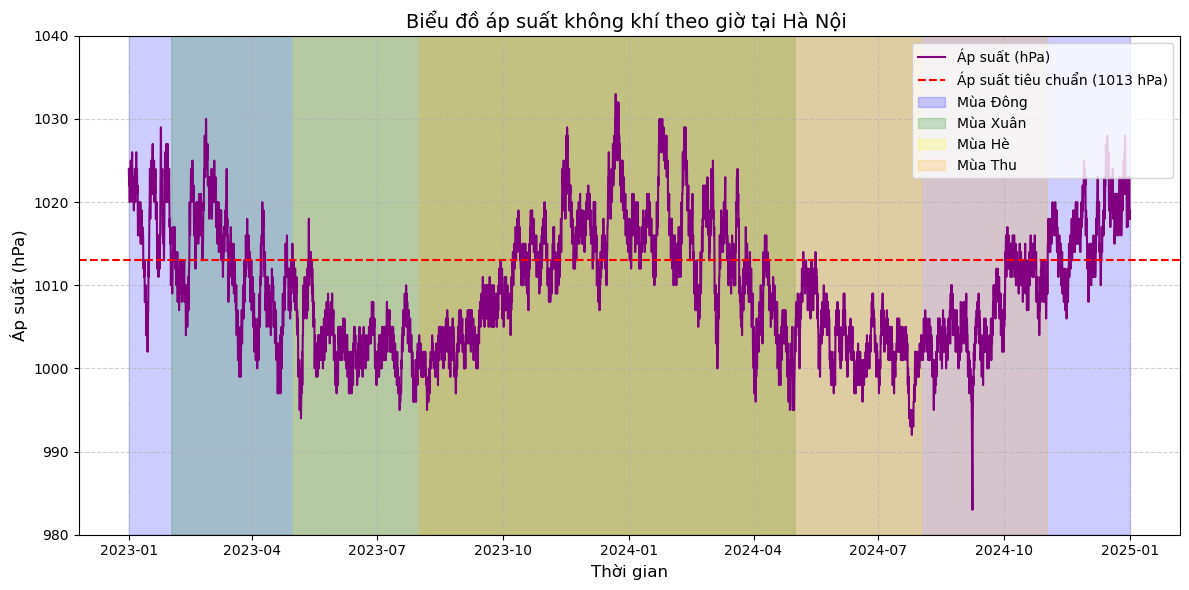

In [110]:
# Xác định các mùa (theo khí tượng học)
mua_dong = [11, 12, 1]
mua_xuan = [2, 3, 4]
mua_he   = [5, 6, 7]
mua_thu  = [8, 9, 10]

# Vẽ biểu đồ áp suất theo thời gian
plt.figure(figsize=(12, 6))
plt.plot(df_2.index, df_2['Pressure'], color='purple', label='Áp suất (hPa)')

# Vẽ đường áp suất tiêu chuẩn (1013 hPa)
plt.axhline(y=1013, color='red', linestyle='--', label='Áp suất tiêu chuẩn (1013 hPa)')

# Tô màu các mùa trong năm
plt.fill_between(df_2.index[df_2.index.month.isin(mua_dong)], 980, 1040, color='blue', alpha=0.2, label='Mùa Đông')
plt.fill_between(df_2.index[df_2.index.month.isin(mua_xuan)], 980, 1040, color='green', alpha=0.2, label='Mùa Xuân')
plt.fill_between(df_2.index[df_2.index.month.isin(mua_he)],   980, 1040, color='yellow', alpha=0.2, label='Mùa Hè')
plt.fill_between(df_2.index[df_2.index.month.isin(mua_thu)],  980, 1040, color='orange', alpha=0.2, label='Mùa Thu')

# Trang trí biểu đồ
plt.title('Biểu đồ áp suất không khí theo giờ tại Hà Nội ', fontsize=14)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Áp suất (hPa)', fontsize=12)
plt.ylim(980, 1040)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 2.5.2 🌤️ Phân tích áp suất trung bình theo mùa tại Hà Nội 

Áp suất khí quyển có sự thay đổi rõ rệt theo mùa, chịu ảnh hưởng bởi **nhiệt độ không khí**, **hướng gió mùa** và **khối khí** hoạt động trên khu vực Bắc Bộ.  
Để hiểu rõ xu hướng này, ta tính toán **giá trị trung bình áp suất (hPa)** cho từng mùa và biểu diễn dưới dạng **biểu đồ cột**.

### 📊 Thông tin biểu đồ
- **Trục X:** Các mùa trong năm  
- **Trục Y:** Áp suất trung bình (hPa)  
- **Cột màu tím:** Áp suất trung bình từng mùa  
- **Đường đứt đỏ:** Áp suất tiêu chuẩn của khí quyển (*1013 hPa*)  

### 🌦️ Diễn giải và ý nghĩa
- **Mùa Đông** thường có **áp suất cao hơn trung bình**, do không khí lạnh tràn về từ phương Bắc.  
- **Mùa Hè** lại có **áp suất thấp hơn**, vì không khí nóng giãn nở làm giảm mật độ không khí.  
- **Mùa Xuân và Mùa Thu** là thời kỳ chuyển tiếp, áp suất dao động quanh mức trung bình.  

### 🎯 Kết quả
Biểu đồ giúp nhận diện:
- Các giai đoạn **áp cao – trời khô lạnh**, dễ xảy ra hiện tượng nghịch nhiệt.  
- Các giai đoạn **áp thấp – không khí ẩm**, thuận lợi cho hình thành mưa, dông.  

Kết hợp với các yếu tố khác như **nhiệt độ**, **độ ẩm**, **tốc độ gió**, phân tích áp suất theo mùa giúp đánh giá **tổng thể điều kiện khí tượng ảnh hưởng đến chất lượng không khí Hà Nội**.


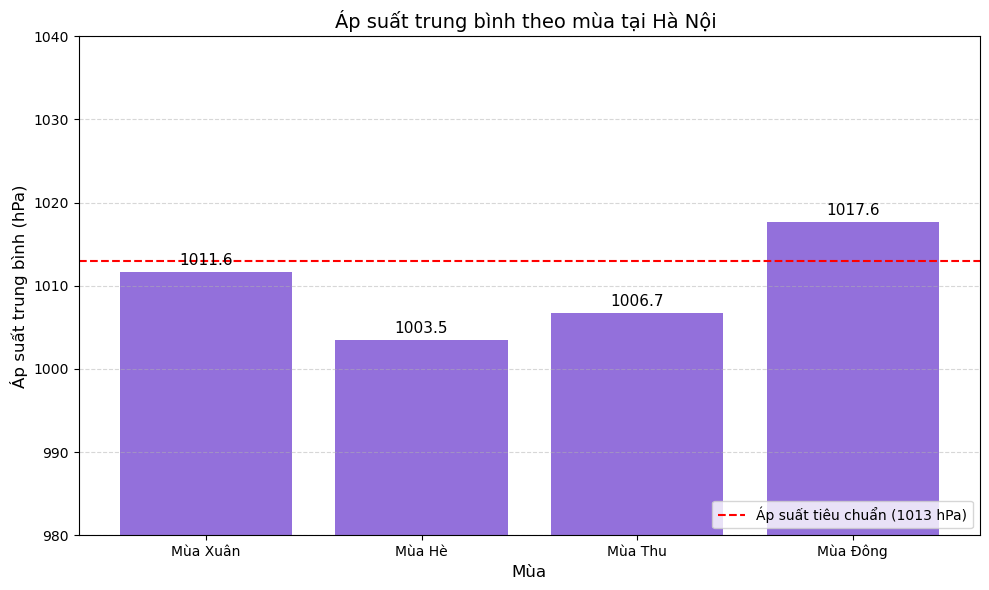

In [111]:
import matplotlib.pyplot as plt

# Xác định các mùa trong năm
cac_mua = {
    'Mùa Xuân': [2, 3, 4],
    'Mùa Hè': [5, 6, 7],
    'Mùa Thu': [8, 9, 10],
    'Mùa Đông': [11, 12, 1]
}

# Tính trung bình áp suất theo từng mùa
ap_suat_trung_binh = {}
for mua, thang in cac_mua.items():
    ap_suat_trung_binh[mua] = df_2.loc[df_2.index.month.isin(thang), 'Pressure'].mean()

# Vẽ biểu đồ cột thể hiện áp suất trung bình theo mùa
plt.figure(figsize=(10, 6))
cot = plt.bar(ap_suat_trung_binh.keys(), ap_suat_trung_binh.values(), color='mediumpurple')

# Vẽ đường áp suất tiêu chuẩn
plt.axhline(y=1013, color='red', linestyle='--', label='Áp suất tiêu chuẩn (1013 hPa)')

# Trang trí biểu đồ
plt.title('Áp suất trung bình theo mùa tại Hà Nội ', fontsize=14)
plt.xlabel('Mùa', fontsize=12)
plt.ylabel('Áp suất trung bình (hPa)', fontsize=12)
plt.ylim(980, 1040)  # Giới hạn hợp lý hơn cho áp suất khí quyển

# Hiển thị giá trị trên đầu mỗi cột
for c in cot:
    chieu_cao = c.get_height()
    plt.text(c.get_x() + c.get_width() / 2, chieu_cao + 0.5, f"{round(chieu_cao, 1)}",
             ha='center', va='bottom', fontsize=11)

plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# 2.6 **Độ ẩm**
## 2.6.1 💧 Phân tích độ ẩm không khí theo thời gian tại Hà Nội (2023)

Độ ẩm tương đối là yếu tố quan trọng phản ánh **mức độ hơi nước trong khí quyển**, ảnh hưởng trực tiếp đến **chất lượng không khí và cảm giác nhiệt của con người**.  
Trong phần này, ta tiến hành **theo dõi sự biến động độ ẩm theo thời gian** trong năm 2023.

### 🌤️ Thông tin biểu đồ
- **Trục X:** Thời gian (theo giờ, trong năm 2023)  
- **Trục Y:** Độ ẩm tương đối (%)  
- **Đường biểu diễn màu xanh lá cây** thể hiện xu hướng biến động độ ẩm theo thời gian.  

### 🎯 Mục tiêu phân tích
- Xác định **giai đoạn trong năm có độ ẩm cao/thấp nhất**.  
- Tính **độ ẩm trung bình cả năm** để đánh giá đặc trưng khí hậu tổng thể.  

### 📊 Kết quả
- Biểu đồ thể hiện rõ các đợt **độ ẩm tăng cao vào mùa nồm (tháng 2–4)**.  
- Mức độ ẩm giảm trong **mùa hè nắng nóng (tháng 6–8)**.  
- **Độ ẩm trung bình cả năm** được tính tự động bằng công thức:

\[
\overline{RH} = \frac{\sum_{i=1}^{n} RH_i}{n}
\]

và được in ra dưới dạng:
> 🌤️ Độ ẩm trung bình năm: **XX.XX%**


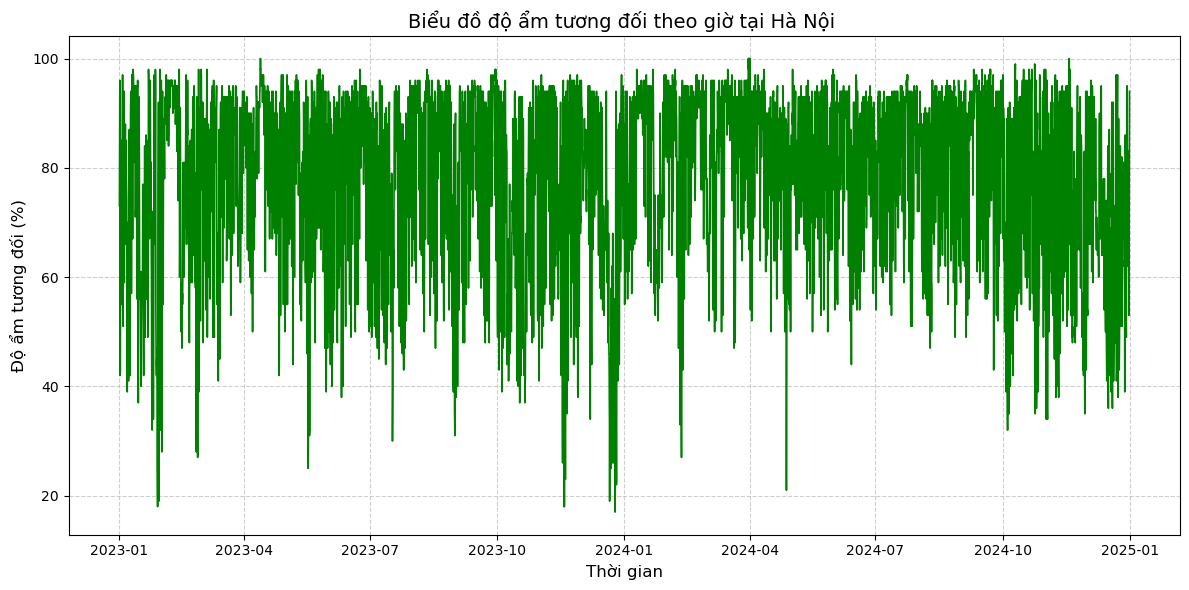

🌤️ Độ ẩm trung bình năm: 77.97%


In [112]:

# Vẽ biểu đồ độ ẩm theo thời gian
plt.figure(figsize=(12, 6))
plt.plot(df_2.index, df_2['Relative Humidity'], color='green', linewidth=1.2)
plt.title('Biểu đồ độ ẩm tương đối theo giờ tại Hà Nội ', fontsize=14)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Độ ẩm tương đối (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Tính trung bình độ ẩm cả năm
do_am_tb_nam = df_2["Relative Humidity"].mean()
print(f"🌤️ Độ ẩm trung bình năm: {do_am_tb_nam:.2f}%")


# 2.7 **Nhiệt Độ**
## 2.7.1 ☀️ Nhiệt độ trung bình theo mùa tại Hà Nội (2023)

Nhiệt độ là yếu tố khí tượng quan trọng phản ánh rõ rệt sự thay đổi theo mùa trong năm.  
Phần này tiến hành **tính toán và trực quan hóa nhiệt độ trung bình của từng mùa tại Hà Nội trong năm 2023**.

### 🌤️ Phân chia mùa khí tượng
| Mùa | Tháng trong năm |
|------|----------------|
| **Mùa Xuân** | 2, 3, 4 |
| **Mùa Hè**   | 5, 6, 7 |
| **Mùa Thu**  | 8, 9, 10 |
| **Mùa Đông** | 11, 12, 1 |

### 🎯 Mục tiêu phân tích
- Xác định **mùa có nhiệt độ trung bình cao nhất** và **thấp nhất**.  
- So sánh **biên độ nhiệt trung bình giữa các mùa**.  
- Minh họa **đặc trưng khí hậu cận nhiệt đới ẩm** của Hà Nội.

### 📊 Giải thích biểu đồ
- Biểu đồ cột thể hiện **nhiệt độ trung bình (℃)** của từng mùa.  
- Mỗi cột hiển thị **giá trị trung bình cụ thể** ngay phía trên.  
- Dữ liệu được tính dựa trên cột `Temperature` trong DataFrame `df_2`.

### 💡 Nhận xét dự kiến
- **Mùa Hè** thường có nhiệt độ cao nhất, trung bình khoảng 30–35℃.  
- **Mùa Đông** có nhiệt độ thấp nhất, trung bình khoảng 15–20℃.  
- **Mùa Xuân** và **Mùa Thu** là hai mùa chuyển tiếp, khí hậu dễ chịu và ổn định hơn.

---



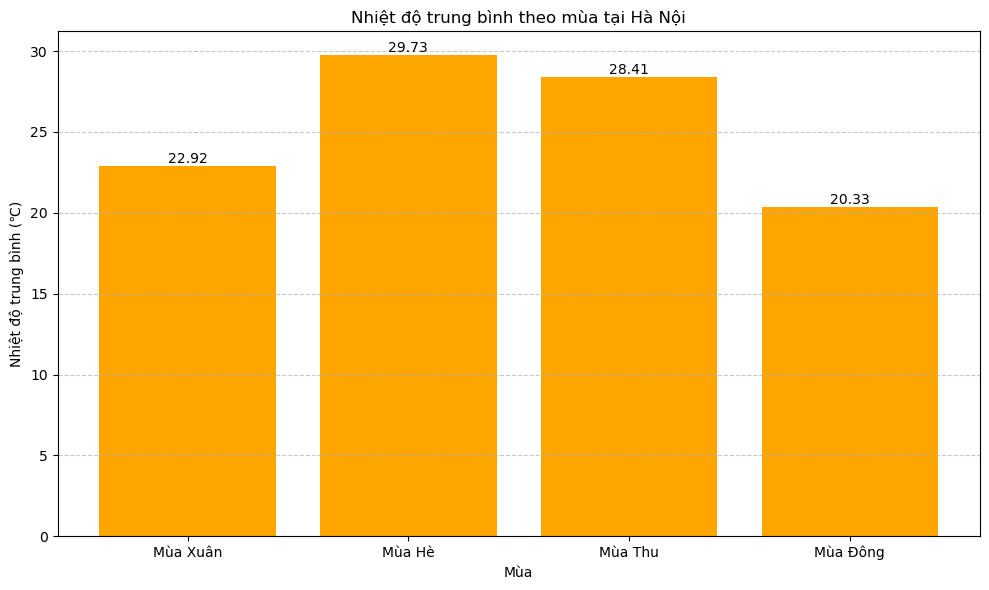

In [114]:
# --- Định nghĩa các mùa ---
mua = {
    'Mùa Xuân': [2, 3, 4],
    'Mùa Hè': [5, 6, 7],
    'Mùa Thu': [8, 9, 10],
    'Mùa Đông': [11, 12, 1]
}

# --- Tính nhiệt độ trung bình theo mùa ---
nhiet_do_theo_mua = {}
for ten_mua, thang in mua.items():
    nhiet_do_theo_mua[ten_mua] = df_2.loc[df_2.index.month.isin(thang), 'Temperature'].mean()

# --- Vẽ biểu đồ ---
plt.figure(figsize=(10, 6))
cot = plt.bar(nhiet_do_theo_mua.keys(), nhiet_do_theo_mua.values(), color='orange')

plt.title('Nhiệt độ trung bình theo mùa tại Hà Nội')
plt.xlabel('Mùa')
plt.ylabel('Nhiệt độ trung bình (℃)')

# --- Ghi giá trị lên đầu cột ---
for thanh in cot:
    cao = thanh.get_height()
    plt.text(thanh.get_x() + thanh.get_width() / 2, cao, round(cao, 2),
             ha='center', va='bottom')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2.8 **Gió**
## 2.8.1 💨 Phân tích tốc độ gió theo mùa tại Hà Nội 

Trong phần này, ta phân tích **sự biến đổi của tốc độ gió** trong năm 2023 tại Hà Nội, đồng thời chia nhỏ dữ liệu theo **4 mùa khí tượng học** để quan sát sự khác biệt theo thời gian:

| Mùa | Tháng |
|-----|-------|
| **Mùa Đông** | 11, 12, 1 |
| **Mùa Xuân** | 2, 3, 4 |
| **Mùa Hè**   | 5, 6, 7 |
| **Mùa Thu**  | 8, 9, 10 |

### 🔍 Mục tiêu phân tích
- Quan sát **xu hướng tốc độ gió** trong năm.  
- Xác định **thời kỳ gió mạnh/yếu nhất**.  
- So sánh tốc độ gió trung bình giữa các mùa.  
- Đánh giá **tốc độ gió trung bình năm** làm mốc tham chiếu.

### 📈 Giải thích biểu đồ
- Đường màu **xám**: thể hiện tốc độ gió theo từng thời điểm (m/s).  
- Vùng màu:
  - 🟦 **Xanh dương nhạt** → Mùa Đông  
  - 🟩 **Xanh lá** → Mùa Xuân  
  - 🟨 **Vàng nhạt** → Mùa Hè  
  - 🟧 **Cam nhạt** → Mùa Thu  
- Đường gạch đỏ `--`: tốc độ gió **trung bình năm**.

Biểu đồ này giúp ta thấy được sự khác biệt rõ rệt của tốc độ gió giữa các mùa:
- **Mùa Đông & Xuân**: thường có tốc độ gió mạnh hơn do ảnh hưởng của gió mùa Đông Bắc.  
- **Mùa Hè**: gió yếu hơn, có thể kèm mưa rào, bão nhiệt đới.  
- **Mùa Thu**: tốc độ gió ổn định và thấp dần về cuối năm.



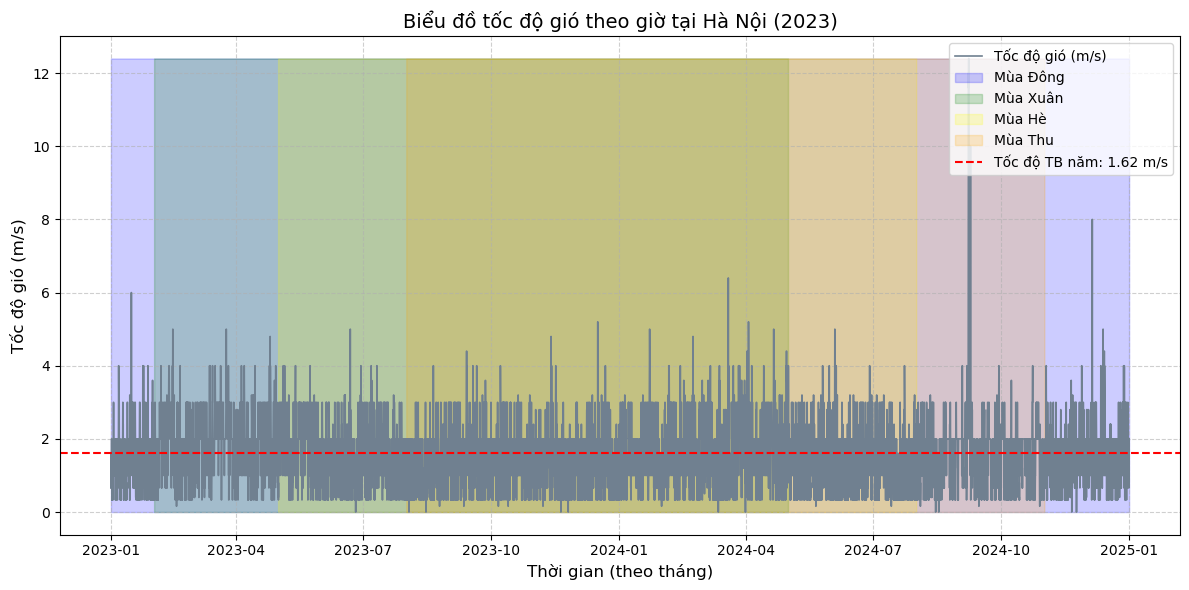

In [115]:


# --- Định nghĩa các mùa (theo khí tượng học) ---
mua_dong = [11, 12, 1]
mua_xuan = [2, 3, 4]
mua_he   = [5, 6, 7]
mua_thu  = [8, 9, 10]

# --- Vẽ biểu đồ tốc độ gió ---
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ đường thể hiện tốc độ gió theo thời gian
plt.plot(df_2.index, df_2['Wind Speed'], color='slategray', linewidth=1.2, label='Tốc độ gió (m/s)')

# --- Tô màu vùng tương ứng với các mùa ---
plt.fill_between(df_2.index[df_2.index.month.isin(mua_dong)],
                 df_2['Wind Speed'].min(), df_2['Wind Speed'].max(),
                 color='blue', alpha=0.2, label='Mùa Đông')

plt.fill_between(df_2.index[df_2.index.month.isin(mua_xuan)],
                 df_2['Wind Speed'].min(), df_2['Wind Speed'].max(),
                 color='green', alpha=0.2, label='Mùa Xuân')

plt.fill_between(df_2.index[df_2.index.month.isin(mua_he)],
                 df_2['Wind Speed'].min(), df_2['Wind Speed'].max(),
                 color='yellow', alpha=0.2, label='Mùa Hè')

plt.fill_between(df_2.index[df_2.index.month.isin(mua_thu)],
                 df_2['Wind Speed'].min(), df_2['Wind Speed'].max(),
                 color='orange', alpha=0.2, label='Mùa Thu')

# --- Tính tốc độ gió trung bình năm ---
toc_do_gio_tb_nam = df_2['Wind Speed'].mean()
plt.axhline(y=toc_do_gio_tb_nam, color='red', linestyle='--', label=f'Tốc độ TB năm: {toc_do_gio_tb_nam:.2f} m/s')

# --- Trang trí biểu đồ ---
plt.title('Biểu đồ tốc độ gió theo giờ tại Hà Nội (2023)', fontsize=14)
plt.xlabel('Thời gian (theo tháng)', fontsize=12)
plt.ylabel('Tốc độ gió (m/s)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# --- In ra giá trị t


## 2.8.2 🍃 Tốc độ gió trung bình theo mùa tại Hà Nội 

Trong phần này, ta tiến hành **phân tích tốc độ gió trung bình của từng mùa trong năm ** nhằm nhận diện xu hướng thay đổi của gió theo mùa khí tượng.

### 🌤️ Phân chia mùa
| Mùa | Tháng trong năm |
|------|----------------|
| **Mùa Xuân** | 2, 3, 4 |
| **Mùa Hạ**   | 5, 6, 7 |
| **Mùa Thu**  | 8, 9, 10 |
| **Mùa Đông** | 11, 12, 1 |

### 🎯 Mục tiêu phân tích
- Xác định **mùa nào có tốc độ gió mạnh nhất/yếu nhất**.  
- So sánh **mức độ chênh lệch tốc độ gió trung bình giữa các mùa**.  
- Đánh giá **tác động của gió mùa Đông Bắc** đến tốc độ gió trung bình năm.

### 📊 Giải thích biểu đồ
- Biểu đồ cột thể hiện **tốc độ gió trung bình (m/s)** của từng mùa.  
- Mỗi cột hiển thị **giá trị trung bình** ngay phía trên.  
- Dữ liệu được tính dựa trên giá trị của cột `Wind Speed` trong `df_2`.

Biểu đồ này giúp trực quan hóa sự khác biệt tốc độ gió giữa bốn mùa:
- 🌀 **Mùa Đông** thường có tốc độ gió cao nhất do ảnh hưởng gió mùa Đông Bắc.  
- 🌦️ **Mùa Hạ** thường có tốc độ gió thấp hơn do khí hậu nóng ẩm, gió yếu.  
- 🍂 **Mùa Thu** và 🌱 **Mùa Xuân** nằm ở mức trung gian và ổn định hơn.


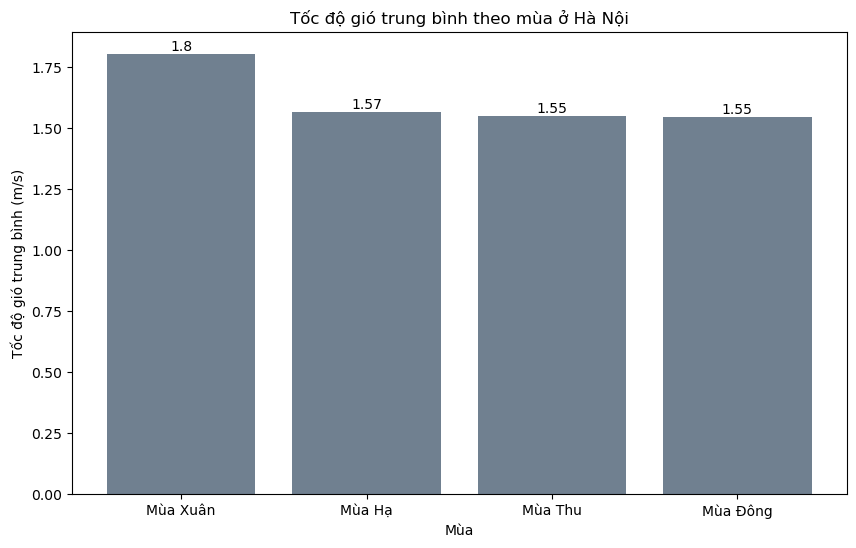

In [116]:
# Định nghĩa các mùa trong năm
mua = {
    'Mùa Xuân': [2, 3, 4],
    'Mùa Hạ': [5, 6, 7],
    'Mùa Thu': [8, 9, 10],
    'Mùa Đông': [11, 12, 1]
}

# Nhóm dữ liệu theo mùa và tính tốc độ gió trung bình cho từng mùa
toc_do_gio_theo_mua = {}
for ten_mua, cac_thang in mua.items():
    toc_do_gio_theo_mua[ten_mua] = df_2.loc[df_2.index.month.isin(cac_thang), 'Wind Speed'].mean()

# Vẽ biểu đồ cột thể hiện tốc độ gió trung bình theo mùa
plt.figure(figsize=(10, 6))
cot = plt.bar(toc_do_gio_theo_mua.keys(), toc_do_gio_theo_mua.values(), color='slategray')

# Tiêu đề và nhãn trục
plt.title('Tốc độ gió trung bình theo mùa ở Hà Nội')
plt.xlabel('Mùa')
plt.ylabel('Tốc độ gió trung bình (m/s)')

# Ghi giá trị trung bình lên đầu mỗi cột
for thanh in cot:
    cao = thanh.get_height()
    plt.text(thanh.get_x() + thanh.get_width() / 2, cao, round(cao, 2),
             ha='center', va='bottom')

# Hiển thị biểu đồ
plt.show()

## 2.9 🔥 Phân tích tương quan giữa các chỉ số ô nhiễm không khí

Để hiểu rõ mối liên hệ giữa các chất gây ô nhiễm, ta sử dụng **ma trận tương quan (Correlation Matrix)** và biểu diễn bằng **biểu đồ nhiệt (Heatmap)**.  
Phân tích này giúp xác định những cặp biến có mối quan hệ **mạnh, yếu, thuận hoặc nghịch** — hỗ trợ trong việc **xây dựng mô hình dự báo chất lượng không khí (AQI)**.

**Các chỉ số được phân tích bao gồm:**
- `AQI` — Chỉ số chất lượng không khí tổng hợp  
- `CO`, `NO2`, `O3`, `SO2` — Các khí ô nhiễm chính  
- `PM10`, `PM25` — Các hạt bụi mịn và siêu mịn  

**Diễn giải Heatmap:**
- Ô màu **đỏ đậm** → Tương quan **thuận mạnh** (r gần +1)  
- Ô màu **xanh đậm** → Tương quan **nghịch mạnh** (r gần -1)  
- Ô màu **trắng nhạt hoặc trung tính** → Tương quan yếu hoặc gần như không có

Phân tích này giúp ta thấy rõ **mối liên hệ giữa các chất ô nhiễm**, ví dụ:
- PM₂.₅ thường **tăng cùng PM₁₀**  
- AQI thường **tăng theo CO hoặc NO₂**  
- O₃ có thể **nghịch biến** với các chất ô nhiễm phát sinh từ giao thông.  



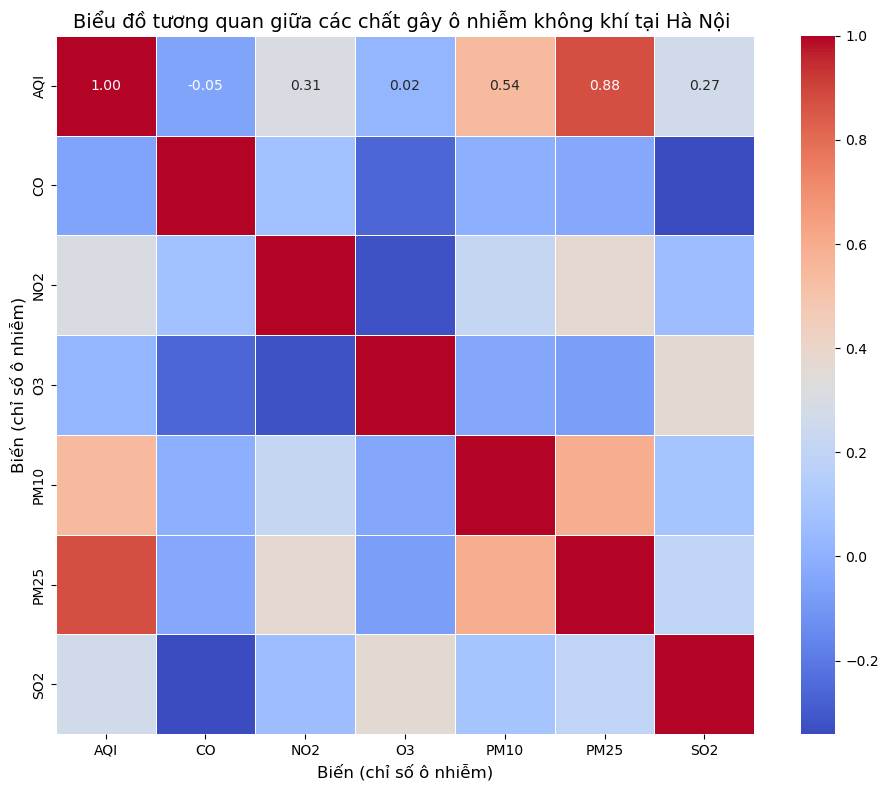

In [127]:

# Chọn các cột cần phân tích tương quan
cot_phan_tich = ['AQI', 'CO', 'NO2', 'O3', 'PM10', 'PM25', 'SO2']

# Tính ma trận tương quan
ma_tran_tuong_quan = df_2[cot_phan_tich].corr()

# Vẽ biểu đồ nhiệt (heatmap) thể hiện mức độ tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(ma_tran_tuong_quan, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, square=True)

# Trang trí biểu đồ
plt.title('Biểu đồ tương quan giữa các chất gây ô nhiễm không khí tại Hà Nội ', fontsize=14)
plt.xlabel('Biến (chỉ số ô nhiễm)', fontsize=12)
plt.ylabel('Biến (chỉ số ô nhiễm)', fontsize=12)
plt.tight_layout()
plt.show()

## 2.10 **Mối quan hệ giữa nồng độ PM2.5 và các chỉ số**


## ☔ Tính số giờ mưa liên tiếp

Đoạn mã dưới đây giúp xác định **số giờ mưa liên tiếp (Accumulated Hours of Rain)** tại mỗi thời điểm.

- Nếu có mưa (`Precipitation > 0`), biến tích lũy tăng thêm 1.
- Nếu không mưa (`Precipitation = 0`), biến tích lũy được đặt lại về 0.
- Kết quả được thêm vào cột mới `Accumulated Hours of Rain` trong `DataFrame df_2`.


In [117]:
# Khởi tạo biến lưu số giờ mưa liên tiếp
accumulated_hours_of_rain = 0

# Tạo danh sách trống để lưu giá trị số giờ mưa tích lũy cho từng dòng
accumulated_hours_list = []

# Duyệt qua từng giá trị lượng mưa trong cột 'Precipitation'
for precipitation in df_2['Precipitation']:
    # Nếu tại giờ hiện tại có mưa (giá trị > 0)
    if precipitation > 0:
        accumulated_hours_of_rain += 1   # cộng thêm 1 giờ mưa
    else:
        accumulated_hours_of_rain = 0     # nếu không mưa, đặt lại về 0
    
    # Thêm giá trị vừa tính vào danh sách
    accumulated_hours_list.append(accumulated_hours_of_rain)

# Thêm danh sách này làm cột mới trong DataFrame
df_2['Accumulated Hours of Rain'] = accumulated_hours_list

# Hiển thị vài dòng đầu tiên để kiểm tra
df_2.head()

,index,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,...,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,month,year,Accumulated Hours of Rain
Local Time,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,0,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,...,87,0.0,1024,73,14.8,0.0,0.66,1,2023,0
2023-01-01 01:00:00,1,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,...,87,0.0,1023,75,14.6,0.0,1.00,1,2023,0
2023-01-01 02:00:00,2,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,...,83,0.0,1023,79,14.3,0.0,1.00,1,2023,0
2023-01-01 03:00:00,3,2022-12-31T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,...,79,0.0,1023,82,14.1,0.0,1.00,1,2023,0
2023-01-01 04:00:00,4,2022-12-31T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,...,75,0.0,1022,86,13.8,0.0,1.00,1,2023,0


## 📊 Phân tích thống kê chuỗi giờ mưa liên tiếp

Đoạn mã sau đây giúp hiển thị **thống kê mô tả** cho cột `Accumulated Hours of Rain`,
giúp ta hiểu rõ về:
- Số giờ mưa trung bình mỗi đợt.
- Chuỗi mưa dài nhất (giá trị `max`).
- Mức độ biến thiên (`std`) của số giờ mưa.


In [118]:
# Kiểm tra thống kê mô tả của cột 'Accumulated Hours of Rain'
print(df_2['Accumulated Hours of Rain'].describe())


count    17544.000000
mean         1.249145
std          4.114975
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         51.000000
Name: Accumulated Hours of Rain, dtype: float64


## 2.10.1 🌧️💨 Phân tích mối quan hệ giữa PM2.5 và số giờ mưa liên tiếp

Trong phần này, ta khảo sát xem liệu **mưa kéo dài** có ảnh hưởng đến **mức độ ô nhiễm không khí (PM2.5)** hay không.  
Biểu đồ phân tán (scatter plot) giúp quan sát mối quan hệ giữa:
- Trục X: Số giờ mưa liên tiếp (`Accumulated Hours of Rain`)
- Trục Y: Nồng độ bụi mịn PM2.5 (`PM25`)

Sau đó, ta vẽ thêm **đường hồi quy tuyến tính (Regression Line)** để thể hiện xu hướng tổng thể.


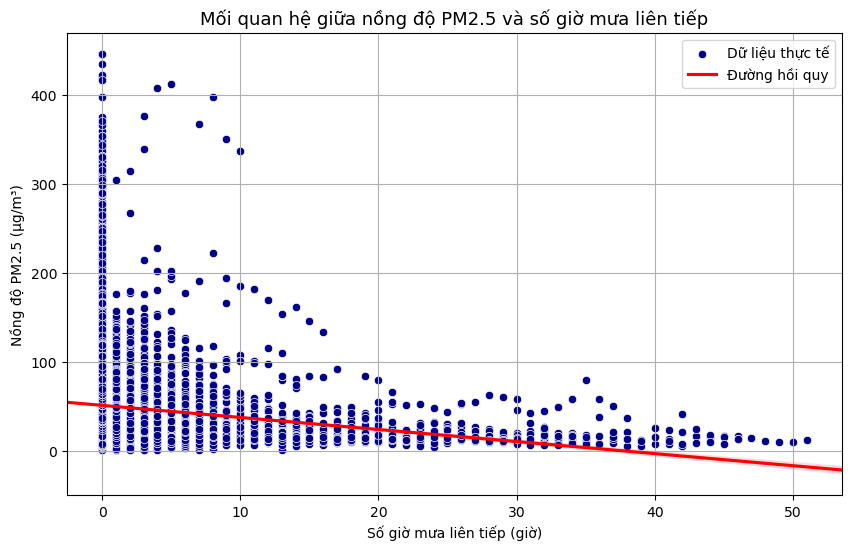

Hệ số tương quan (Correlation Coefficient): -0.13


In [119]:
# --- Vẽ biểu đồ phân tán (Scatter plot) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_2, x='Accumulated Hours of Rain', y='PM25', color='darkblue', label='Dữ liệu thực tế')

# --- Vẽ đường hồi quy (Regression line) ---
sns.regplot(data=df_2, x='Accumulated Hours of Rain', y='PM25', truncate=False, scatter=False, color='red', label='Đường hồi quy')

# --- Tính hệ số tương quan ---
correlation_coefficient = df_2['Accumulated Hours of Rain'].corr(df_2['PM25'])

# --- Thiết lập tiêu đề và nhãn ---
plt.title('Mối quan hệ giữa nồng độ PM2.5 và số giờ mưa liên tiếp', fontsize=13)
plt.xlabel('Số giờ mưa liên tiếp (giờ)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')
plt.legend()
plt.grid(True)
plt.show()

# --- In hệ số tương quan ---
print(f"Hệ số tương quan (Correlation Coefficient): {correlation_coefficient:.2f}")

## 2.10.2 💧 Phân tích mối quan hệ giữa PM2.5 và độ ẩm không khí

Trong phần này, ta khảo sát xem **độ ẩm không khí** có ảnh hưởng đến **mức độ ô nhiễm PM2.5** tại Hà Nội hay không.  
Biểu đồ phân tán (scatter plot) được sử dụng để biểu diễn mối quan hệ giữa:
- **Trục X**: Độ ẩm tương đối (%)
- **Trục Y**: Nồng độ bụi mịn PM2.5 (μg/m³)

Đồng thời, ta thêm **đường hồi quy tuyến tính (Regression line)** để thể hiện xu hướng tổng thể của dữ liệu.


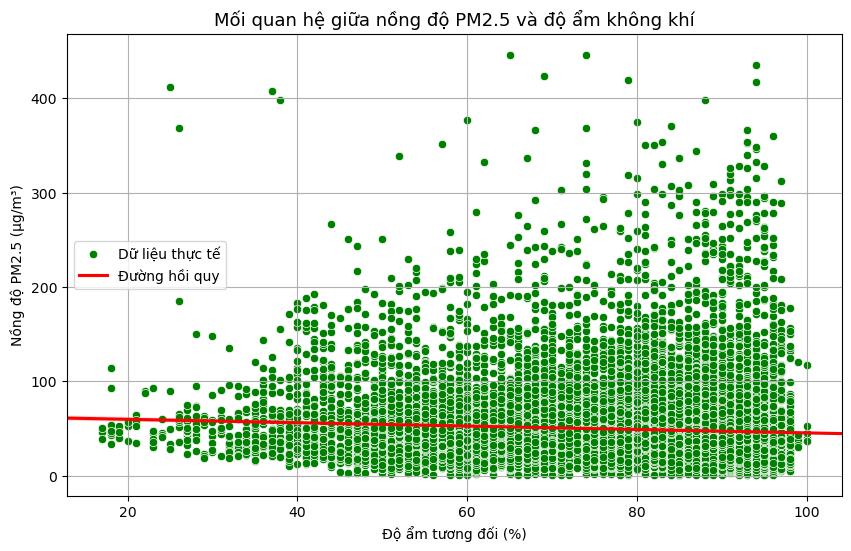

Hệ số tương quan (Correlation Coefficient): -0.06


In [120]:
# --- Vẽ biểu đồ phân tán (Scatter plot) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_2, x='Relative Humidity', y='PM25', color='green', label='Dữ liệu thực tế')

# --- Vẽ đường hồi quy tuyến tính (Regression line) ---
sns.regplot(data=df_2, x='Relative Humidity', y='PM25', truncate=False, color='red', scatter=False, label='Đường hồi quy')

# --- Tính hệ số tương quan ---
correlation_coefficient = df_2['Relative Humidity'].corr(df_2['PM25'])

# --- Thiết lập tiêu đề và nhãn ---
plt.title('Mối quan hệ giữa nồng độ PM2.5 và độ ẩm không khí', fontsize=13)
plt.xlabel('Độ ẩm tương đối (%)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')
plt.legend()
plt.grid(True)
plt.show()

# --- In hệ số tương quan ---
print(f"Hệ số tương quan (Correlation Coefficient): {correlation_coefficient:.2f}")


## 2.10.3 🌬️ Phân tích mối quan hệ giữa PM2.5 và áp suất không khí

Áp suất khí quyển có thể ảnh hưởng đến khả năng khuếch tán và tích tụ các hạt bụi mịn (PM2.5).  
Trong phần này, ta sử dụng biểu đồ **phân tán (Scatter Plot)** và **đường hồi quy tuyến tính** để khảo sát mối quan hệ giữa:
- **Trục X:** Áp suất (hPa)  
- **Trục Y:** Nồng độ PM2.5 (μg/m³)  

Đồng thời, hệ số tương quan Pearson (*r*) được tính toán để định lượng mức độ liên hệ giữa hai biến.

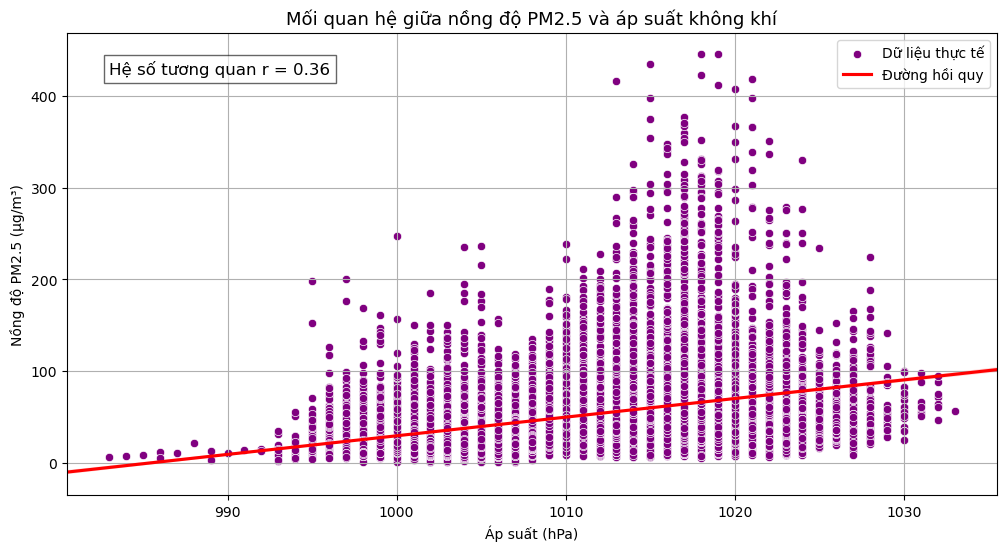

Hệ số tương quan (Correlation Coefficient): 0.36


In [121]:
# --- Vẽ biểu đồ phân tán (Scatter plot) ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_2, x='Pressure', y='PM25', color='purple', label='Dữ liệu thực tế')

# --- Vẽ đường hồi quy tuyến tính (Regression line) ---
sns.regplot(data=df_2, x='Pressure', y='PM25', truncate=False, color='red', scatter=False, label='Đường hồi quy')

# --- Tính hệ số tương quan ---
correlation_coefficient = df_2['Pressure'].corr(df_2['PM25'])

# --- Thiết lập tiêu đề và nhãn ---
plt.title('Mối quan hệ giữa nồng độ PM2.5 và áp suất không khí', fontsize=13)
plt.xlabel('Áp suất (hPa)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')
plt.legend()
plt.grid(True)

# --- Thêm chú thích hệ số tương quan trên biểu đồ ---
plt.text(x=df_2['Pressure'].min(), 
         y=df_2['PM25'].max()*0.95, 
         s=f"Hệ số tương quan r = {correlation_coefficient:.2f}", 
         color='black', 
         fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.6))

plt.show()

# --- In ra hệ số tương quan ---
print(f"Hệ số tương quan (Correlation Coefficient): {correlation_coefficient:.2f}")


## 2.10.4 🌡️ Phân tích mối quan hệ giữa PM2.5 và Nhiệt độ không khí

Nhiệt độ không khí là yếu tố quan trọng ảnh hưởng đến **sự khuếch tán và hình thành các hạt bụi mịn (PM2.5)**.  
Khi nhiệt độ tăng, luồng đối lưu trong khí quyển thường mạnh hơn, giúp **khuếch tán các hạt bụi tốt hơn**, từ đó **làm giảm nồng độ PM2.5**.  
Ngược lại, khi nhiệt độ thấp, đặc biệt vào ban đêm hoặc mùa lạnh, **sự nghịch nhiệt (temperature inversion)** có thể xảy ra, khiến các chất ô nhiễm bị “mắc kẹt” gần mặt đất và **làm tăng nồng độ PM2.5**.

**Trong phần này:**
- **Trục X:** Nhiệt độ không khí (°C)  
- **Trục Y:** Nồng độ bụi mịn PM2.5 (μg/m³)  
- **Đường đỏ:** Đường hồi quy tuyến tính thể hiện xu hướng tổng quát  
- **Hệ số tương quan Pearson (r):** cho biết mức độ liên hệ giữa hai biến

**Diễn giải:**
- Nếu *r < 0*: mối quan hệ **nghịch biến** (nhiệt độ tăng → PM2.5 giảm)  
- Nếu *r > 0*: mối quan hệ **thuận biến** (nhiệt độ tăng → PM2.5 tăng)  
- Nếu *|r| ≈ 0*: hầu như không có mối tương quan rõ rệt  

Biểu đồ giúp chúng ta nhận diện **xu hướng tổng thể** giữa biến động nhiệt độ và mức độ ô nhiễm bụi mịn tại khu vực Hà Nội.


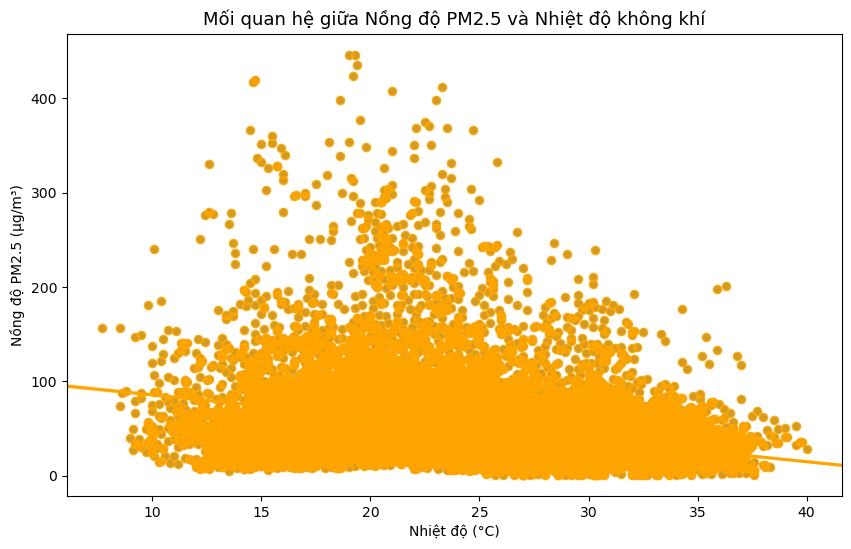

Correlation Coefficient: -0.31


In [124]:
# Vẽ biểu đồ phân tán giữa Nhiệt độ và Nồng độ PM2.5
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_2, x='Temperature', y='PM25')

# Vẽ đường hồi quy (màu cam)
sns.regplot(data=df_2, x='Temperature', y='PM25', truncate=False, color='orange')

# Tính hệ số tương quan giữa nhiệt độ và PM2.5
correlation_coefficient = df_2['Temperature'].corr(df_2['PM25'])

# Thêm tiêu đề và nhãn trục
plt.title('Mối quan hệ giữa Nồng độ PM2.5 và Nhiệt độ không khí', fontsize=13)
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')

# Hiển thị biểu đồ
plt.show()

# Print correlation coefficient
print(f"Correlation Coefficient: {correlation_coefficient:.2f}")

## 2.10.5 💨 Phân tích mối quan hệ giữa PM2.5 và Tốc độ gió

Tốc độ gió là một trong những yếu tố **ảnh hưởng trực tiếp đến sự khuếch tán của bụi mịn (PM2.5)** trong không khí.  
Gió mạnh có thể **giúp phân tán các hạt bụi**, làm **giảm nồng độ PM2.5**, trong khi **gió yếu hoặc không có gió** thường khiến các hạt bụi **tích tụ gần mặt đất**, làm **tăng mức độ ô nhiễm**.

**Trong phần này:**
- **Trục X:** Tốc độ gió (m/s)  
- **Trục Y:** Nồng độ PM2.5 (μg/m³)  
- **Đường xám:** Đường hồi quy tuyến tính biểu thị xu hướng chung  
- **Hệ số tương quan Pearson (r):** thể hiện mức độ liên hệ giữa hai biến

**Diễn giải:**
- Nếu *r < 0*: Mối quan hệ **nghịch biến** → gió mạnh hơn → bụi mịn giảm  
- Nếu *r > 0*: Mối quan hệ **thuận biến** → gió mạnh hơn → bụi mịn tăng  
- Nếu *|r| nhỏ*: Không có mối liên hệ rõ rệt giữa hai biến  

Kết quả này giúp đánh giá vai trò của **yếu tố khí tượng (tốc độ gió)** trong việc **làm loãng hoặc tích tụ chất ô nhiễm PM2.5** tại Hà Nội.


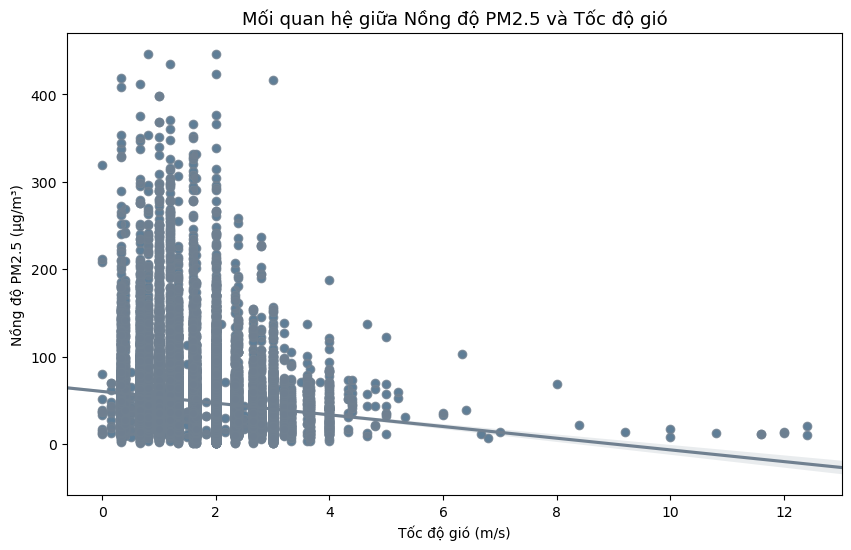

Hệ số tương quan (r): -0.13


In [125]:
# Vẽ biểu đồ phân tán giữa Tốc độ gió và Nồng độ PM2.5
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_2, x='Wind Speed', y='PM25')

# Vẽ đường hồi quy (màu xám)
sns.regplot(data=df_2, x='Wind Speed', y='PM25', truncate=False, color='slategray')

# Tính hệ số tương quan giữa tốc độ gió và PM2.5
correlation_coefficient = df_2['Wind Speed'].corr(df_2['PM25'])

# Thêm tiêu đề và nhãn trục
plt.title('Mối quan hệ giữa Nồng độ PM2.5 và Tốc độ gió', fontsize=13)
plt.xlabel('Tốc độ gió (m/s)')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')

# Hiển thị biểu đồ
plt.show()

# In ra hệ số tương quan
print(f"Hệ số tương quan (r): {correlation_coefficient:.2f}")